## Gene Network Pipeline

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import json
import os

### Gene Definition in CARD

In [2]:
# Each gene: name, family, drug classes it resists, mechanism
GENES = [
    # Beta-lactamases
    {"id": "CTX-M",   "family": "ESBL",         "classes": ["beta_lactam"],            "mechanism": "inactivation", "clinical_risk": "high"},
    {"id": "TEM",     "family": "ESBL",         "classes": ["beta_lactam"],            "mechanism": "inactivation", "clinical_risk": "medium"},
    {"id": "SHV",     "family": "ESBL",         "classes": ["beta_lactam"],            "mechanism": "inactivation", "clinical_risk": "medium"},
    {"id": "KPC",     "family": "Carbapenemase","classes": ["beta_lactam"],            "mechanism": "inactivation", "clinical_risk": "critical"},
    {"id": "NDM",     "family": "Carbapenemase","classes": ["beta_lactam"],            "mechanism": "inactivation", "clinical_risk": "critical"},
    {"id": "VIM",     "family": "Carbapenemase","classes": ["beta_lactam"],            "mechanism": "inactivation", "clinical_risk": "critical"},
    {"id": "IMP",     "family": "Carbapenemase","classes": ["beta_lactam"],            "mechanism": "inactivation", "clinical_risk": "critical"},
    {"id": "OXA-48",  "family": "Carbapenemase","classes": ["beta_lactam"],            "mechanism": "inactivation", "clinical_risk": "critical"},
    # Aminoglycoside
    {"id": "AAC(6')", "family": "AME",          "classes": ["aminoglycoside"],         "mechanism": "inactivation", "clinical_risk": "medium"},
    {"id": "AAC(3)",  "family": "AME",          "classes": ["aminoglycoside"],         "mechanism": "inactivation", "clinical_risk": "medium"},
    {"id": "ANT",     "family": "AME",          "classes": ["aminoglycoside"],         "mechanism": "inactivation", "clinical_risk": "medium"},
    # Quinolone
    {"id": "QNR",     "family": "QRP",          "classes": ["quinolone"],              "mechanism": "target_protection", "clinical_risk": "medium"},
    {"id": "GyrA mut","family": "Mutation",     "classes": ["quinolone"],              "mechanism": "target_alteration", "clinical_risk": "high"},
    # Colistin
    {"id": "MCR",     "family": "Phosphotransferase","classes": ["other"],             "mechanism": "target_alteration", "clinical_risk": "critical"},
    # Sulfonamide
    {"id": "Sul1",    "family": "Sulfonamide R","classes": ["other"],                  "mechanism": "target_replacement", "clinical_risk": "low"},
    {"id": "DfrA",    "family": "Dihydrofolate R","classes": ["other"],               "mechanism": "target_replacement", "clinical_risk": "low"},
    # Efflux pumps — broad spectrum
    {"id": "RND pump","family": "Efflux",       "classes": ["beta_lactam","quinolone","aminoglycoside","other"], "mechanism": "efflux", "clinical_risk": "high"},
    {"id": "MFS pump","family": "Efflux",       "classes": ["quinolone","other"],      "mechanism": "efflux", "clinical_risk": "medium"},
    # Porin loss
    {"id": "OmpF loss","family": "Porin",       "classes": ["beta_lactam","aminoglycoside"], "mechanism": "permeability", "clinical_risk": "medium"},
]

# Dominant species per gene (from CARD literature)
GENE_SPECIES = {
    "CTX-M"   : ["E. coli", "K. pneumoniae", "Enterobacter"],
    "TEM"     : ["E. coli", "K. pneumoniae", "Proteus"],
    "SHV"     : ["K. pneumoniae"],
    "KPC"     : ["K. pneumoniae", "Enterobacter"],
    "NDM"     : ["K. pneumoniae", "A. baumannii", "E. coli"],
    "VIM"     : ["P. aeruginosa", "K. pneumoniae"],
    "IMP"     : ["P. aeruginosa", "Enterobacter"],
    "OXA-48"  : ["K. pneumoniae", "E. coli"],
    "AAC(6')" : ["E. coli", "K. pneumoniae", "P. aeruginosa"],
    "AAC(3)"  : ["E. coli", "P. aeruginosa"],
    "ANT"     : ["E. coli", "P. aeruginosa"],
    "QNR"     : ["E. coli", "K. pneumoniae"],
    "GyrA mut": ["E. coli", "P. aeruginosa"],
    "MCR"     : ["E. coli", "K. pneumoniae"],
    "Sul1"    : ["E. coli"],
    "DfrA"    : ["E. coli"],
    "RND pump": ["P. aeruginosa", "A. baumannii", "E. coli"],
    "MFS pump": ["E. coli", "K. pneumoniae"],
    "OmpF loss":["E. coli", "K. pneumoniae"],
}

### Build NetworkX graph

In [3]:
G = nx.Graph()

# Color maps
RISK_COLOR = {
    "critical": "#e74c3c",
    "high"    : "#e67e22",
    "medium"  : "#f1c40f",
    "low"     : "#2ecc71",
}
MECH_COLOR = {
    "inactivation"     : "#e74c3c",
    "efflux"           : "#9b59b6",
    "target_alteration": "#3498db",
    "target_protection": "#1abc9c",
    "target_replacement": "#27ae60",
    "permeability"     : "#95a5a6",
}
CLASS_COLOR = {
    "beta_lactam"   : "#e74c3c",
    "aminoglycoside": "#3498db",
    "quinolone"     : "#2ecc71",
    "other"         : "#9b59b6",
}

# Add gene nodes
for gene in GENES:
    G.add_node(
        gene["id"],
        node_type="gene",
        family=gene["family"],
        mechanism=gene["mechanism"],
        clinical_risk=gene["clinical_risk"],
        classes=gene["classes"],
        color=RISK_COLOR[gene["clinical_risk"]],
        size=30 if gene["clinical_risk"] == "critical" else
             20 if gene["clinical_risk"] == "high" else 15,
    )

# Add drug class nodes
drug_classes = ["beta_lactam", "aminoglycoside", "quinolone", "other"]
class_labels = {
    "beta_lactam"   : "Beta-lactam",
    "aminoglycoside": "Aminoglycoside",
    "quinolone"     : "Quinolone",
    "other"         : "Other (Colistin\nCotrimoxazole\nNitrofurantoin)",
}
for dc in drug_classes:
    G.add_node(dc, node_type="drug_class", color=CLASS_COLOR[dc], size=40)

# Add edges: gene → drug class
for gene in GENES:
    for dc in gene["classes"]:
        G.add_edge(gene["id"], dc, weight=2,
                   color=MECH_COLOR[gene["mechanism"]])

# Add co-occurrence edges between genes sharing species
gene_ids = [g["id"] for g in GENES]
for i, g1 in enumerate(gene_ids):
    for g2 in gene_ids[i+1:]:
        sp1 = set(GENE_SPECIES.get(g1, []))
        sp2 = set(GENE_SPECIES.get(g2, []))
        shared = sp1 & sp2
        if len(shared) >= 2:
            G.add_edge(g1, g2, weight=len(shared),
                       color="#444444", style="dashed")

### Plot

Saved: outputs/gene_network_static.png


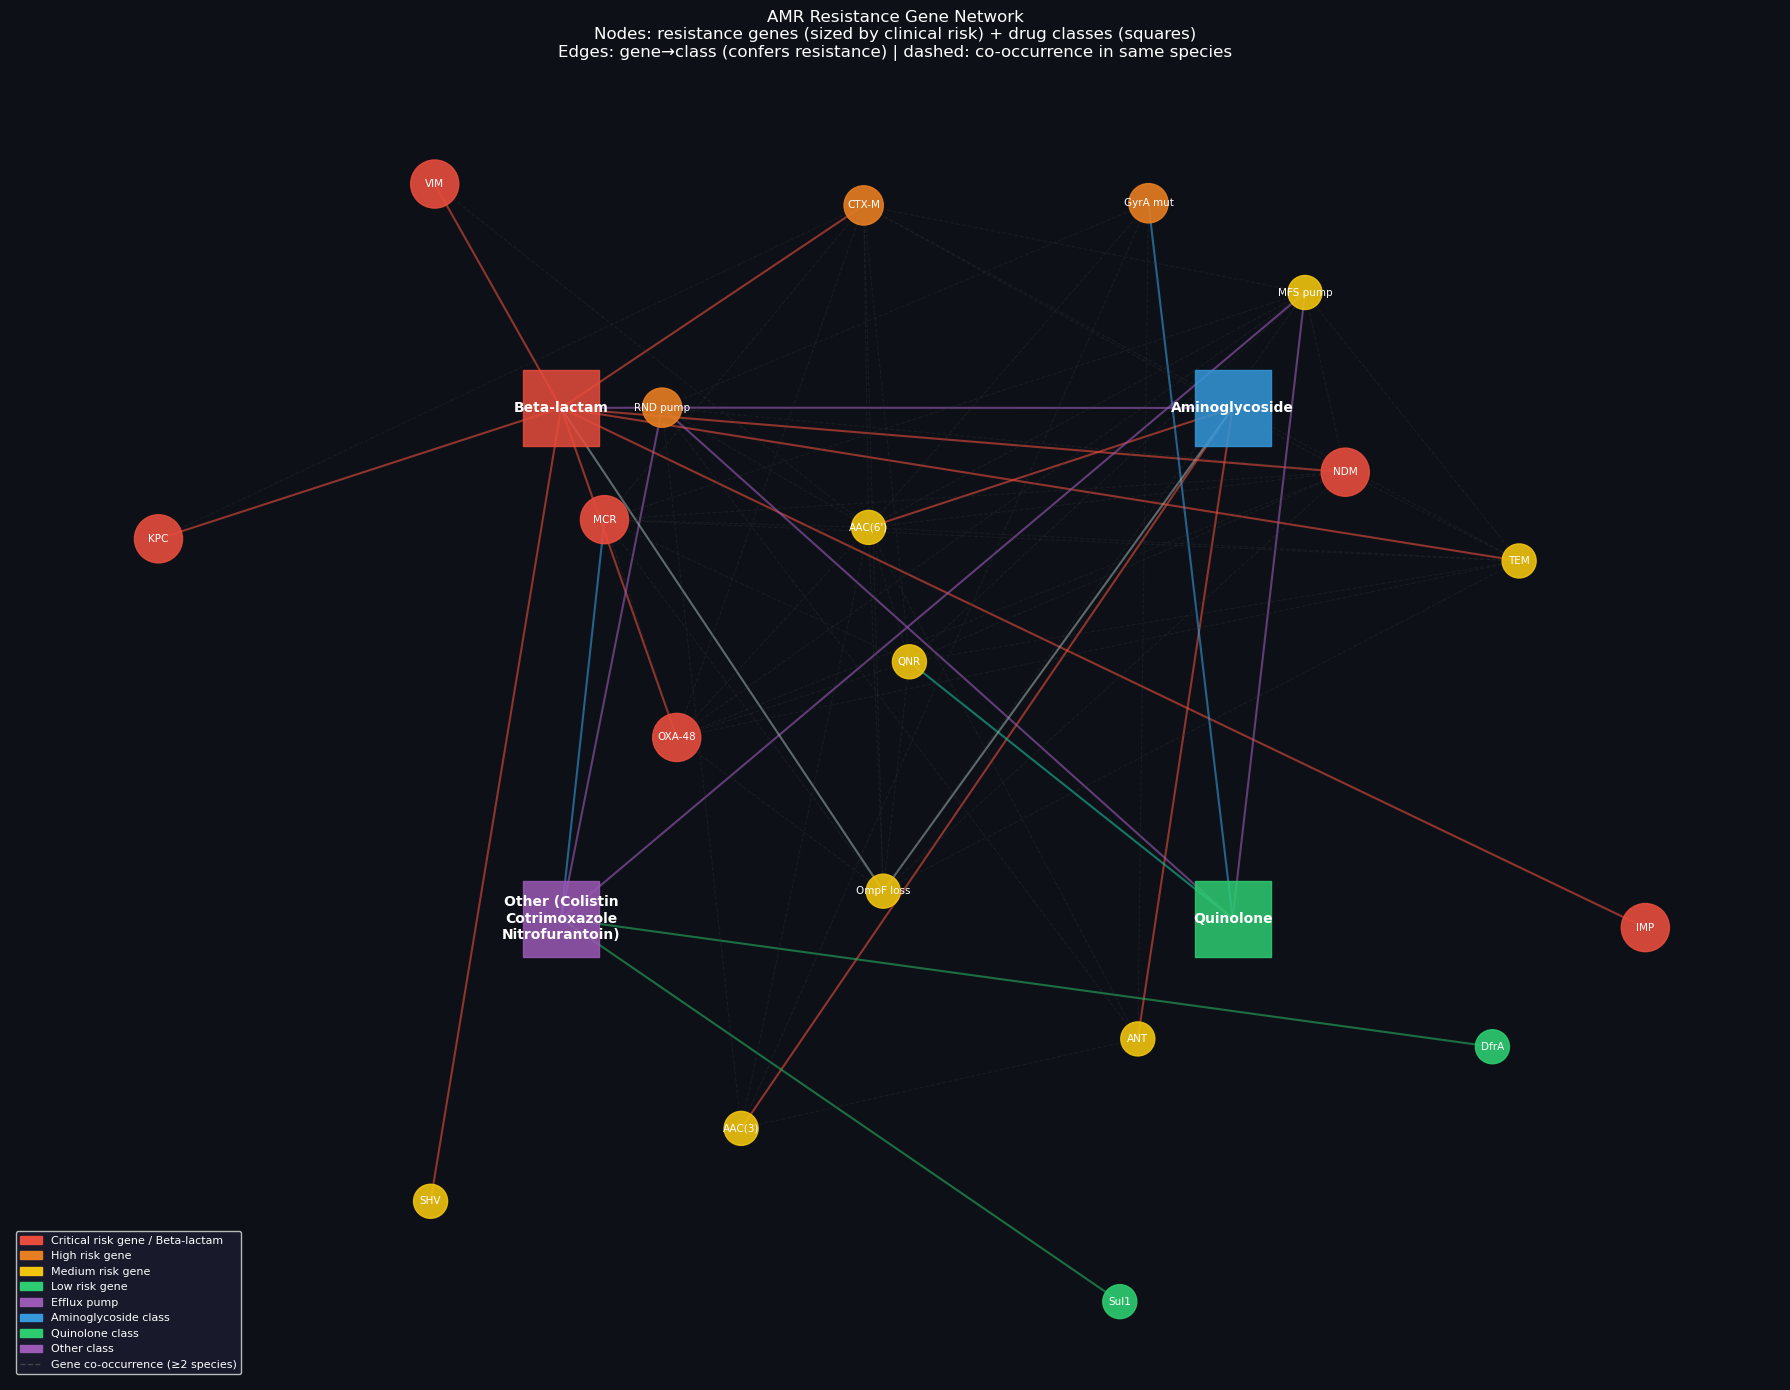

In [4]:
fig, ax = plt.subplots(figsize=(18, 14))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

# Layout — drug class nodes at center ring, genes around outside
pos = nx.spring_layout(G, seed=42, k=2.5)

# Override drug class positions to be in center
drug_pos = {
    "beta_lactam"   : np.array([-0.4,  0.4]),
    "aminoglycoside": np.array([ 0.4,  0.4]),
    "quinolone"     : np.array([ 0.4, -0.4]),
    "other"         : np.array([-0.4, -0.4]),
}
for dc, p in drug_pos.items():
    pos[dc] = p

# Draw edges
gene_gene_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('style') == 'dashed']
gene_class_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('style') != 'dashed']

# Gene-class edges (colored by mechanism)
for u, v in gene_class_edges:
    d = G.edges[u, v]
    nx.draw_networkx_edges(G, pos, edgelist=[(u, v)],
        edge_color=d.get('color', '#666'),
        alpha=0.6, width=1.5, ax=ax)

# Gene co-occurrence edges (dashed gray)
nx.draw_networkx_edges(G, pos, edgelist=gene_gene_edges,
    edge_color='#333', alpha=0.3, width=0.8,
    style='dashed', ax=ax)

# Draw drug class nodes (large squares)
drug_node_list = [n for n in G.nodes if G.nodes[n]['node_type'] == 'drug_class']
nx.draw_networkx_nodes(G, pos, nodelist=drug_node_list,
    node_color=[CLASS_COLOR[n] for n in drug_node_list],
    node_size=3000, node_shape='s', alpha=0.85, ax=ax)

# Draw gene nodes (circles, sized by risk)
gene_node_list = [n for n in G.nodes if G.nodes[n]['node_type'] == 'gene']
gene_colors = [G.nodes[n]['color'] for n in gene_node_list]
gene_sizes  = [G.nodes[n]['size'] * 40 for n in gene_node_list]
nx.draw_networkx_nodes(G, pos, nodelist=gene_node_list,
    node_color=gene_colors, node_size=gene_sizes,
    alpha=0.9, ax=ax)

# Labels
drug_labels = {n: class_labels[n] for n in drug_node_list}
nx.draw_networkx_labels(G, pos, labels=drug_labels,
    font_size=10, font_color='white', font_weight='bold', ax=ax)

gene_labels = {n: n for n in gene_node_list}
nx.draw_networkx_labels(G, pos, labels=gene_labels,
    font_size=7.5, font_color='white', ax=ax)

# Legend
legend_elements = [
    mpatches.Patch(color='#e74c3c', label='Critical risk gene / Beta-lactam'),
    mpatches.Patch(color='#e67e22', label='High risk gene'),
    mpatches.Patch(color='#f1c40f', label='Medium risk gene'),
    mpatches.Patch(color='#2ecc71', label='Low risk gene'),
    mpatches.Patch(color='#9b59b6', label='Efflux pump'),
    mpatches.Patch(color='#3498db', label='Aminoglycoside class'),
    mpatches.Patch(color='#2ecc71', label='Quinolone class'),
    mpatches.Patch(color='#9b59b6', label='Other class'),
    plt.Line2D([0], [0], color='#444', lw=1, ls='--', label='Gene co-occurrence (≥2 species)'),
]
ax.legend(handles=legend_elements, loc='lower left',
          facecolor='#1a1a2e', labelcolor='white',
          fontsize=8, framealpha=0.9)

ax.set_title(
    'AMR Resistance Gene Network\n'
    'Nodes: resistance genes (sized by clinical risk) + drug classes (squares)\n'
    'Edges: gene→class (confers resistance) | dashed: co-occurrence in same species',
    color='white', fontsize=12, pad=15
)
ax.axis('off')

plt.tight_layout()
plt.savefig('outputs/gene_network_static.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
print("Saved: outputs/gene_network_static.png")
plt.show()
plt.close()


### Interactive Pyvis HTML

In [8]:
try:
    from pyvis.network import Network

    net = Network(
        height="700px", width="100%",
        bgcolor="#0d1117", font_color="#ffffff",
        notebook=False,
    )
    net.barnes_hut(gravity=-8000, central_gravity=0.3,
                   spring_length=150, spring_strength=0.04)

    for node in G.nodes(data=True):
        nid = node[0]
        d   = node[1]
        if d['node_type'] == 'drug_class':
            net.add_node(nid,
                label=class_labels.get(nid, nid),
                color=CLASS_COLOR.get(nid, '#666'),
                size=40, shape='square',
                title=f"Drug class: {nid.replace('_',' ').title()}",
                font={'size': 16, 'bold': True},
            )
        else:
            gene_data = next((g for g in GENES if g['id'] == nid), {})
            sp_list   = ', '.join(GENE_SPECIES.get(nid, ['Unknown']))
            net.add_node(nid,
                label=nid,
                color=RISK_COLOR.get(d['clinical_risk'], '#888'),
                size=d['size'],
                title=(f"{nid}"
                       f"Family: {gene_data.get('family','')}"
                       f"Mechanism: {gene_data.get('mechanism','')}"
                       f"Clinical risk: {d['clinical_risk']}"
                       f"Species: {sp_list}"),
            )

    for u, v, d in G.edges(data=True):
        is_dashed = d.get('style') == 'dashed'
        net.add_edge(u, v,
            color=d.get('color', '#444'),
            width=1.5 if not is_dashed else 0.8,
            dashes=is_dashed,
            title="Co-occurrence in ≥2 species" if is_dashed else "Confers resistance",
        )

    net.save_graph('outputs/resistance_gene_network.html')
    print("Saved: outputs/resistance_gene_network.html")

except ImportError:
    print("pyvis not installed — skipping interactive HTML.")
    print("Install with: pip install pyvis")
    print("Static PNG saved to outputs/gene_network_static.png")

print("\nDone. Files saved to outputs/")

Saved: outputs/resistance_gene_network.html

Done. Files saved to outputs/
